This Notebook will contain the implementatation of MoE architcture.

ok now simple reminder - what is MoE?
MoE stands for mixure of experts, which all it does, it replaces the single dense FFN with N specialized sub-networks calles "experts". During inference time, only top-k experts activates and handle each token, keepin compute cheap while it can scale.

It also has a gating network, which takes the input, and outputs a probability distribution over experts, and then picks top-k experts. All this does it routuing.


Load balancing loss - penalizes the model if tokens pile up on a few experts — forces specialization AND fairness.


What we do here - we build:
- Gate - router
- individual FFN/experts
- combine these in one MoE layer
- training with load-balancer
- see which experts activates during the inference
- visualise expert load distributions


```
text  →  tokenizer  →  embedding  →  MoE transformer block  →  next-token prediction
```


In [78]:
%pip install torch matplotlib numpy


[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [107]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from collections import defaultdict
from datasets import load_dataset
from transformers import AutoTokenizer

torch.manual_seed(42)
np.random.seed(42)


if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_built() and torch.backends.mps.is_available():
    # CPU is the most reliable fallback in this workspace; MPS embedding storage
    # has been flaky here during notebook validation.
    device = torch.device("cpu")
    
print(f'Using device: {device}')

Using device: cpu


In [108]:
#  tokenizer wrapper
#  using a public tokenizer keeps the notebook shorter and closer to what
#  real LLM pretraining code uses.

class HFTokenizerAdapter:
    """
    Thin wrapper around a Hugging Face tokenizer.

    GPT-2 uses a byte-level BPE tokenizer, so this keeps the notebook aligned with
    a standard modern LLM tokenizer instead of a hand-built character vocabulary.

    Exposes the small interface the notebook expects:
    - encode(text) -> LongTensor
    - decode(ids)  -> string
    - vocab_size
    - stoi / itos for convenience in a few analysis cells
    """

    def __init__(self, model_name: str = 'gpt2'):
        self.tokenizer = AutoTokenizer.from_pretrained(model_name)
        if self.tokenizer.pad_token is None:
            self.tokenizer.pad_token = self.tokenizer.eos_token

        vocab = self.tokenizer.get_vocab()
        self.stoi = vocab
        self.itos = {idx: token for token, idx in vocab.items()}
        self.vocab_size = self.tokenizer.vocab_size

        print(f'Vocab size: {self.vocab_size} tokens')
        print(f'Tokenizer: {model_name}')

    def encode(self, text: str, max_length: int | None = None, truncation: bool = False) -> torch.Tensor:
        """text → 1-D LongTensor of token ids."""
        ids = self.tokenizer.encode(
            text,
            add_special_tokens=False,
            max_length=max_length,
            truncation=truncation,
        )
        return torch.tensor(ids, dtype=torch.long)

    def decode(self, ids) -> str:
        """Token ids → string."""
        if isinstance(ids, torch.Tensor):
            ids = ids.tolist()
        return self.tokenizer.decode(ids, skip_special_tokens=True, clean_up_tokenization_spaces=False)


In [109]:
# ── OpenWebText corpus ─────────────────────────────────────────────
NUM_DOCS = 5000

def load_openwebtext(num_docs: int = 5000) -> str:
    """Stream a small OpenWebText sample into a single text corpus."""
    print(f'Streaming {num_docs} documents from OpenWebText...')
    owt = load_dataset(
        'Skylion007/openwebtext',
        split='train',
        streaming=True,
    )
    docs = list(owt.take(num_docs))
    text = '\n'.join(doc['text'] for doc in docs)
    print(f'Loaded {num_docs} documents ({len(text):,} characters)\n')
    return text

# A public byte-level BPE tokenizer is simpler than maintaining a custom
# character vocabulary.
# GPT-2 is a convenient default because it is broadly available in Transformers.
tokenizer = HFTokenizerAdapter('gpt2')
corpus = load_openwebtext(num_docs=NUM_DOCS)

# ── Quick test ───────────────────────────────────────────────────────
sample = 'to be'
ids    = tokenizer.encode(sample)
back   = tokenizer.decode(ids)
print(f'\nEncode: {repr(sample)} → {ids.tolist()}')
print(f'Decode: {ids.tolist()} → {repr(back)}')

Vocab size: 50257 tokens
Tokenizer: gpt2
Streaming 5000 documents from OpenWebText...


Resolving data files:   0%|          | 0/80 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/80 [00:00<?, ?it/s]

Loaded 5000 documents (24,434,929 characters)


Encode: 'to be' → [1462, 307]
Decode: [1462, 307] → 'to be'


In [110]:
#  Embedding layer
class TokenEmbedding(nn.Module):
    """
    Token embedding + learned positional embedding.

    Args:
        vocab_size : V — number of unique tokens
        d_model    : embedding dimension
        max_seq    : maximum sequence length we'll ever see
    """
    def __init__(self, vocab_size: int, d_model: int, max_seq: int = 128):
        super().__init__()
        # Token embedding: each token id maps to a d_model-dim vector
        self.tok_emb = nn.Embedding(vocab_size, d_model)

        # Positional embedding: each position 0..max_seq maps to a d_model-dim vector
        self.pos_emb = nn.Embedding(max_seq, d_model)

        self.d_model = d_model

    def forward(self, token_ids: torch.Tensor) -> torch.Tensor:
        """
        token_ids : [B, S]  — integer token indices
        returns   : [B, S, d_model]
        """
        B, S = token_ids.shape

        # positions: [0, 1, 2, ..., S-1] broadcast over batch
        positions = torch.arange(S, device=token_ids.device).unsqueeze(0)  # [1, S]

        tok = self.tok_emb(token_ids)   # [B, S, d_model]
        pos = self.pos_emb(positions)   # [1, S, d_model]  → broadcasts over B

        return tok + pos    

In [111]:

# ── Quick test ───────────────────────────────────────────────────────
D_MODEL = 64
emb_layer = TokenEmbedding(vocab_size=tokenizer.vocab_size, d_model=D_MODEL)

ids_batch = tokenizer.encode('to be or not').unsqueeze(0)  # [1, 4]
emb_out   = emb_layer(ids_batch)

print(f'Token ids shape  : {ids_batch.shape}')   # [1, 4]
print(f'Embedding output : {emb_out.shape}')      # [1, 4, 64]
print(f'Each token is now a {D_MODEL}-dim vector')

Token ids shape  : torch.Size([1, 4])
Embedding output : torch.Size([1, 4, 64])
Each token is now a 64-dim vector


some questions:
**what is capacity factor?**
capacity factor is a hyperparameter that controls how many token each expert is allowed to process in a batch.

the main idea is for MoE, many tokens are routed to a small number of experts, but gpus need fixed-size tensors, so we must cap how many tokens each expert recieves. this cap is the expert capacity, and the capacity factor controls how big that cap is

**What about w_g?**
this is a learnable linear map that computes (logits = W_g x). What it does, it basically implements the gating fucntion that map each token to expert scores.
so for each token it follows:
d_dim token embedding -> linear projection (W_g) -> n_exp logits (expert scores)
so it answers the quesion of which ecpert should this token go to, and how strongly?

so in summary the below line is learned routing classifier that scores each expert for every token via a linear projection.

self.w_g = nn.Linear(d, n_exp, bias=False) # router projection matric

why no bias? bias can destabilizer expert load balancing

**What about the noise?**
so noise is used in top-k gating (from the original MoE paper). So what this does, this is not directly add noise, it produces noise scale (standard deviation) per expert

so mathematically -> logitsi​=gi​(x)+σi​(x)⋅ϵi​

why this exist? because router is determinstic and same tokens always end up with same experts. This is not good because it causes expert starvation/collaps. Some experts are always used and some never used at all.

so each expert gets a ;earned uncertainty about routing decisions so:
confident routing → small σ
uncertain routing → large σ

so in summary -> learned per-expert uncertainty model that produces stochastic perturbations to routing logits to prevent expert collapse and improve load balancing

so its not a random noise - its a learned noise

In [112]:
#  implementation of gate network - router
import math
import torch
from torch import nn
from torch.nn import functional as F


class Router(nn.Module):
    def __init__(
        self,
        d,
        n_exp=8,
        top_k=2,
        use_noisy_top_k=True,
        capacity_factor=1.25,
    ):
        """
        Router does three jobs:
        1. score every expert for every token,
        2. pick the top-k experts,
        3. build fixed-size expert batches that the experts can process efficiently.

        Arguments:
        d: size of embedding dimension
        n_exp: number of experts in the expert layer
        top_k: number of active experts for each token
        use_noisy_top_k: whether to add learned noise before top-k selection
        capacity_factor: scales the expert capacity used for token packing
        """
        super().__init__()

        self.d = d
        self.n_exp = n_exp
        self.top_k = top_k
        if not (1 <= self.top_k <= n_exp):
            raise ValueError(
                f"top_k must be between 1 and n_exp ({n_exp}), "
                f"but got top_k={self.top_k}"
            )
        self.use_noisy_top_k = use_noisy_top_k
        self.capacity_factor = capacity_factor
        self.w_g = nn.Linear(d, n_exp, bias=False)  # router projection matrix
        self.w_noise = nn.Linear(d, n_exp, bias=False) if self.use_noisy_top_k else None

    def _load_balance_loss(self, top_k_indices: torch.Tensor, router_probs: torch.Tensor) -> torch.Tensor:
        """Switch Transformer auxiliary loss.

        The loss encourages the router to both:
        - send tokens to experts more uniformly, and
        - assign probability mass more uniformly.

        It follows the same structure as the notebook snippet from Switch Transformer:
        L_aux = N * sum_i(f_i * P_i)
        """
        with torch.no_grad():
            one_hot_indices = F.one_hot(top_k_indices, num_classes=self.n_exp).float()
            one_hot_indices = torch.sum(one_hot_indices, dim=2)  # [B, C, N]
            tokens_per_expert = torch.mean(one_hot_indices, dim=(0, 1))

        prob_per_expert = torch.mean(router_probs.float(), dim=(0, 1))
        return self.n_exp * torch.sum(prob_per_expert * tokens_per_expert)

    def _router_z_loss(self, router_logits: torch.Tensor) -> torch.Tensor:
        """ST-MoE router z-loss.

        This regularizes the size of the router logits directly, which helps keep the
        softmax numerically stable during pretraining.
        """
        return torch.mean(torch.logsumexp(router_logits.float(), dim=-1) ** 2.0)

    def forward(self, x):  # define the computation of the model
        # get the total number of tokens in the batch
        # B -> batch size
        # C -> sequence length
        # d -> embedding dimension
        B, C, _ = x.size()
        num_tokens = B * C

        # Compute router logits in the same way as the reference nanoMoE implementation.
        router_logits = self.w_g(x)  # [B, C, d] -> [B, C, n_exp]
        if self.use_noisy_top_k:
            # Optional learned noise regularizes the router and helps avoid collapse.
            noise = F.softplus(self.w_noise(x))  # ensures sigma > 0
            noise *= torch.randn_like(noise)  # epsilon ~ N(0, 1)
            router_logits = router_logits + noise

        # Keep the routing math in float32 for stability, even if the model is trained
        # under mixed precision.
        router_logits_fp32 = router_logits.float()

        # Top-k expert selection and softmax over only the selected experts.
        top_k_logits, top_k_indices = router_logits_fp32.topk(self.top_k, dim=-1)  # [B, C, K]
        router_probs = torch.full_like(router_logits_fp32, float("-inf"))  # [B, C, n_exp]
        router_probs.scatter_(-1, top_k_indices, top_k_logits)
        router_probs = F.softmax(router_probs, dim=-1)

        # Auxiliary losses used during pretraining.
        load_balance_loss = self._load_balance_loss(top_k_indices, router_probs)
        router_z_loss = self._router_z_loss(router_logits_fp32)

        # Compute the expert capacity.
        # This is the maximum number of tokens any expert is allowed to receive.
        exp_capacity = math.floor(self.top_k * self.capacity_factor * num_tokens / self.n_exp)
        exp_capacity += exp_capacity % 2  # keep the capacity even for cleaner packing
        exp_capacity = max(2, int(exp_capacity))

        # Build a multi-hot routing mask for the selected experts.
        # K is the top-k routing rank, so the first dimension tracks top-1, top-2, etc.
        exp_mask = F.one_hot(top_k_indices, num_classes=self.n_exp)  # [B, C, K, n_exp]
        exp_mask = exp_mask.view(num_tokens, self.top_k, self.n_exp)  # [B * C, K, n_exp]
        exp_mask = exp_mask.permute(1, 0, 2)  # [K, B * C, n_exp]

        # Compute the slot index for every token inside each expert batch.
        # cumsum gives a stable ordering so that top-1 tokens are kept before top-2 tokens.
        exp_rank = exp_mask.reshape(self.top_k * num_tokens, self.n_exp)  # [K * B * C, n_exp]
        exp_rank = torch.cumsum(exp_rank, dim=0) - 1
        exp_rank = exp_rank.reshape(self.top_k, num_tokens, self.n_exp)  # [K, B * C, n_exp]

        # Drop assignments that exceed expert capacity.
        exp_mask = exp_mask * torch.lt(exp_rank, exp_capacity)

        # Recover the rank of each surviving token within its chosen expert.
        exp_rank = torch.sum(exp_mask * exp_rank, dim=-1)  # [K, B * C]

        # Mask probabilities to only include the selected and capacity-approved experts.
        router_probs = router_probs.view(num_tokens, self.n_exp)[None, :]  # [1, B * C, n_exp]
        exp_weights = exp_mask * router_probs  # [K, B * C, n_exp]

        # Turn the slot index into a one-hot tensor so we can build fixed-size expert batches.
        exp_rank_sc = F.one_hot(exp_rank, num_classes=exp_capacity)  # [K, B * C, exp_capacity]

        # Final sparse routing weights for each expert slot.
        exp_weights = torch.sum(exp_weights.unsqueeze(3) * exp_rank_sc.unsqueeze(2), dim=0)
        dispatch_mask = exp_weights.bool()

        # Pack tokens into expert batches.
        x = x.view(num_tokens, self.d)
        expert_batches = dispatch_mask.permute(1, 2, 0).type_as(x) @ x

        info = {
            "weights": router_probs.detach(),  # full [B, C, N] gate probabilities
            "router_logits": router_logits_fp32.detach(),
            "topk_idx": top_k_indices.detach(),
            "exp_capacity": exp_capacity,
            "dispatch_mask": dispatch_mask.detach(),
        }

        return exp_weights, dispatch_mask, expert_batches, load_balance_loss, router_z_loss, info

In [113]:
#  quick sanity check
gate = Router(d=8, n_exp=4, top_k=2,
               use_noisy_top_k=True, capacity_factor=2)
x_dummy = torch.randn(2, 3, 8)          # batch=2, seq=3, d=8
weights, token_mask, expert_batches, lb_loss, z_loss, info = gate(x_dummy)

print('Gate output weights shape :', weights.shape)      # [B*C, n_exp, capacity]
print('Token mask shape          :', token_mask.shape)   # [K, B*C, n_exp]
print('Expert batches shape      :', expert_batches.shape)  # [n_exp, capacity, d]
print('Load-balance loss         :', lb_loss.item())
print('Router z-loss             :', z_loss.item())

active_experts = token_mask.any(dim=0).view(2, 3, -1)
chosen = [
    [torch.where(active_experts[b, s])[0].tolist() for s in range(active_experts.size(1))]
    for b in range(active_experts.size(0))
]

print('Non-zero entries per token:', active_experts.sum(-1))  # should be 2 everywhere
print('Chosen expert indices      :', chosen)
print('Expert capacity            :', info['exp_capacity'])

Gate output weights shape : torch.Size([6, 4, 6])
Token mask shape          : torch.Size([6, 4, 6])
Expert batches shape      : torch.Size([4, 6, 8])
Load-balance loss         : 2.117581844329834
Router z-loss             : 1.5090283155441284
Non-zero entries per token: tensor([[4, 2, 1],
        [3, 2, 0]])
Chosen expert indices      : [[[0, 1, 2, 3], [2, 3], [0]], [[0, 1, 2], [2, 3], []]]
Expert capacity            : 6


In [114]:
#  individual experts
class Expert(nn.Module):
    """
    A single feed-forward expert.
    Each expert owns its own parameters, just like the dense MLP in a decoder-only
    transformer, except that the router selects which experts run for each token.

    Architecture: Linear -> GELU -> Linear -> Dropout
    """
    def __init__(self, d_model: int, d_ff: int, dropout: float = 0.1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(d_model, d_ff, bias=False),
            nn.GELU(),
            nn.Linear(d_ff, d_model, bias=False),
            nn.Dropout(dropout),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # The expert operates pointwise on the token batch it receives.
        return self.net(x)


In [115]:
# ── Sanity check ──
expert = Expert(d_model=8, d_ff=32)
x_tok = torch.randn(5, 8)   # 5 tokens, d_model=8
print('Expert output shape:', expert(x_tok).shape)  # [5, 8]

Expert output shape: torch.Size([5, 8])


In [116]:
#  MoE layer - putting this together

class MoELayer(nn.Module):
    """
    Mixture-of-Experts layer.

    This follows the nanoMoE routing recipe:
    1. route each token to its top-k experts,
    2. pack tokens into fixed-size expert batches,
    3. run each expert on its own batch,
    4. recombine expert outputs with the router weights.

    Args:
        d_model     : token embedding dimension
        d_ff        : hidden size of each expert FFN
        num_experts : total number of experts
        top_k       : number of experts active per token
        use_noisy_top_k : adds learned router noise before top-k selection
        capacity_factor  : scales the static expert capacity
    """
    def __init__(
        self,
        d_model: int,
        d_ff: int,
        num_experts: int,
        top_k: int,
        use_noisy_top_k: bool = True,
        capacity_factor: float = 1.25,
    ):
        super().__init__()
        self.num_experts = num_experts
        self.top_k = top_k

        # Router that scores experts, builds batches, and computes auxiliary losses.
        self.router = Router(
            d=d_model,
            n_exp=num_experts,
            top_k=top_k,
            use_noisy_top_k=use_noisy_top_k,
            capacity_factor=capacity_factor,
        )

        # Each expert is an independent MLP.
        self.experts = nn.ModuleList(
            [Expert(d_model, d_ff) for _ in range(num_experts)]
        )

    def forward(self, x: torch.Tensor):
        """
        x : [B, S, D]  - batch of sequences

        Returns
        -------
        out              : [B, S, D]  - MoE output
        load_balance_loss : scalar     - Switch-style auxiliary loss
        router_z_loss     : scalar     - logit-norm regularizer
        info             : dict        - routing metadata for analysis
        """
        B, S, D = x.shape

        # Route tokens and get a fixed-size batch for each expert.
        exp_weights, exp_mask, expert_batches, load_balance_loss, router_z_loss, info = self.router(x)

        # Run each expert on the tokens it received.
        # This mirrors the nanoMoE formulation where we batch expert computation.
        expert_outputs = []
        for expert_idx, expert in enumerate(self.experts):
            expert_outputs.append(expert(expert_batches[expert_idx]))
        expert_outputs = torch.stack(expert_outputs, dim=0)  # [N, capacity, D]

        # Recombine expert outputs using the sparse router weights.
        # Flattening here gives us the same matrix multiplication used in nanoMoE.
        out = exp_weights.reshape(B * S, -1) @ expert_outputs.reshape(-1, D)
        out = out.view(B, S, D)

        info = {
            **info,
            "exp_weights": exp_weights.detach(),
            "exp_mask": exp_mask.detach(),
            "expert_batches": expert_batches.detach(),
        }

        return out, load_balance_loss, router_z_loss, info


In [117]:
# ── Sanity check ───────────────────────────────────────────────────
moe = MoELayer(d_model=16, d_ff=64, num_experts=4, top_k=2).to(device)
x_in = torch.randn(4, 10, 16).to(device)   # batch=4, seq=10, d=16

out, load_balance_loss, router_z_loss, info = moe(x_in)
print('MoE output shape    :', out.shape)       # [4, 10, 16]
print('Load-balance loss   :', load_balance_loss.item())
print('Router z-loss       :', router_z_loss.item())
print('Routing indices     :', info['topk_idx'].shape)  # [4, 10, 2]
print('Expert batches      :', info['expert_batches'].shape)


MoE output shape    : torch.Size([4, 10, 16])
Load-balance loss   : 2.0192136764526367
Router z-loss       : 2.9471018314361572
Routing indices     : torch.Size([4, 10, 2])
Expert batches      : torch.Size([4, 26, 16])


In [118]:
#  MoE transformer block  - self attention

class CausalSelfAttention(nn.Module):
    """
    Multi-head causal (masked) self-attention.
    'Causal' means each token can only attend to itself and previous tokens.
    This is the autoregressive property that makes next-token prediction work.
    """
    def __init__(self, d_model: int, n_heads: int, max_seq: int = 128):
        super().__init__()
        assert d_model % n_heads == 0, 'd_model must be divisible by n_heads'

        self.n_heads = n_heads
        self.head_dim = d_model // n_heads

        # Q, K, V projections (all in one matrix for efficiency)
        self.qkv  = nn.Linear(d_model, 3 * d_model, bias=False)
        self.proj = nn.Linear(d_model, d_model, bias=False)

        # Causal mask: upper-triangular -inf so future tokens are invisible
        mask = torch.triu(torch.ones(max_seq, max_seq), diagonal=1).bool()
        self.register_buffer('causal_mask', mask)   # saved as non-parameter buffer

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        B, S, D = x.shape

        # Project to Q, K, V and split into heads
        qkv = self.qkv(x)                          # [B, S, 3*D]
        q, k, v = qkv.chunk(3, dim=-1)             # each [B, S, D]

        # Reshape to [B, n_heads, S, head_dim]
        def split_heads(t):
            return t.view(B, S, self.n_heads, self.head_dim).transpose(1, 2)

        q, k, v = split_heads(q), split_heads(k), split_heads(v)

        # Scaled dot-product attention
        scale  = self.head_dim ** -0.5
        scores = (q @ k.transpose(-2, -1)) * scale  # [B, H, S, S]

        # Apply causal mask (mask out future positions)
        scores = scores.masked_fill(self.causal_mask[:S, :S], float('-inf'))
        attn   = F.softmax(scores, dim=-1)

        # Weighted sum of values
        out = (attn @ v)                            # [B, H, S, head_dim]
        out = out.transpose(1, 2).contiguous().view(B, S, D)  # merge heads
        return self.proj(out)                       # [B, S, D]


In [119]:
class MoETransformerBlock(nn.Module):
    """
    One transformer block where the FFN is replaced by a MoE layer.

    Structure:
        x -> LN -> Attention -> + x   (residual connection)
          -> LN -> MoE       -> + x   (residual connection)
    """
    def __init__(self, d_model, n_heads, d_ff, num_experts, top_k, use_noisy_top_k=True, capacity_factor=1.25, max_seq=128):
        super().__init__()
        self.ln1 = nn.LayerNorm(d_model)
        self.attn = CausalSelfAttention(d_model, n_heads, max_seq)
        self.ln2 = nn.LayerNorm(d_model)
        self.moe = MoELayer(
            d_model,
            d_ff,
            num_experts,
            top_k,
            use_noisy_top_k=use_noisy_top_k,
            capacity_factor=capacity_factor,
        )

    def forward(self, x):
        # Attention sub-layer with a residual connection.
        x = x + self.attn(self.ln1(x))

        # MoE sub-layer with a residual connection.
        moe_out, load_balance_loss, router_z_loss, info = self.moe(self.ln2(x))
        x = x + moe_out

        return x, load_balance_loss, router_z_loss, info


In [120]:
class MoELanguageModel(nn.Module):
    def __init__(
        self,
        vocab_size,
        d_model=64,
        n_heads=4,
        d_ff=256,
        num_experts=6,
        top_k=2,
        n_layers=2,
        max_seq=128,
        use_noisy_top_k=True,
        capacity_factor=1.25,
    ):
        super().__init__()
        self.embedding = TokenEmbedding(vocab_size, d_model, max_seq)

        self.blocks = nn.ModuleList([
            MoETransformerBlock(
                d_model,
                n_heads,
                d_ff,
                num_experts,
                top_k,
                use_noisy_top_k=use_noisy_top_k,
                capacity_factor=capacity_factor,
                max_seq=max_seq,
            )
            for _ in range(n_layers)
        ])

        self.ln_final = nn.LayerNorm(d_model)

        # Language model head: project d_model -> vocab_size to get token logits.
        self.lm_head = nn.Linear(d_model, vocab_size, bias=False)

        # Weight tying is common in decoder-only LMs, but we keep the head untied here
        # to avoid backend-specific issues on some accelerator paths.

        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.normal_(m.weight, std=0.02)
            elif isinstance(m, nn.Embedding):
                nn.init.normal_(m.weight, std=0.02)

    def forward(self, token_ids):
        """
        token_ids : [B, S]  - integer token indices

        Returns
        -------
        logits             : [B, S, vocab_size]  - next-token scores
        load_balance_loss   : scalar              - summed across MoE layers
        router_z_loss       : scalar              - summed across MoE layers
        all_info            : list of dicts       - routing info per layer
        """
        x = self.embedding(token_ids)  # [B, S, d_model]

        total_load_balance_loss = torch.zeros((), device=x.device, dtype=x.dtype)
        total_router_z_loss = torch.zeros((), device=x.device, dtype=x.dtype)
        all_info = []

        for block in self.blocks:
            x, load_balance_loss, router_z_loss, info = block(x)
            total_load_balance_loss = total_load_balance_loss + load_balance_loss
            total_router_z_loss = total_router_z_loss + router_z_loss
            all_info.append(info)

        x = self.ln_final(x)  # [B, S, d_model]
        logits = self.lm_head(x)  # [B, S, vocab_size]

        return logits, total_load_balance_loss, total_router_z_loss, all_info


In [121]:
# ── Hyperparameters ───────────────────────────────────────────────────
N_EXPERTS  = 6
TOP_K      = 2
D_MODEL    = 64
N_HEADS    = 4
D_FF       = 256
N_LAYERS   = 2
MAX_SEQ    = 64
USE_NOISY_TOP_K = True
CAPACITY_FACTOR  = 1.25

LOAD_BALANCE_ALPHA = 0.01
ROUTER_Z_ALPHA     = 0.001

model = MoELanguageModel(
    vocab_size       = tokenizer.vocab_size,
    d_model          = D_MODEL,
    n_heads          = N_HEADS,
    d_ff             = D_FF,
    num_experts      = N_EXPERTS,
    top_k            = TOP_K,
    n_layers         = N_LAYERS,
    max_seq          = MAX_SEQ,
    use_noisy_top_k   = USE_NOISY_TOP_K,
    capacity_factor   = CAPACITY_FACTOR,
).to(device)

total_params = sum(p.numel() for p in model.parameters())
print(f'Total parameters : {total_params:,}')
print(f'Vocab size       : {tokenizer.vocab_size}')
print(f'Experts per layer: {N_EXPERTS}  |  top-K: {TOP_K}')
print(f'Layers           : {N_LAYERS}')
print(f'Capacity factor  : {CAPACITY_FACTOR}')
print(f'Router noise     : {USE_NOISY_TOP_K}')


Total parameters : 6,865,152
Vocab size       : 50257
Experts per layer: 6  |  top-K: 2
Layers           : 2
Capacity factor  : 1.25
Router noise     : True


#  Training data  - build (input, target) pairs
For next-token prediction we slide a window over the corpus:

```
corpus:  t  o     b  e     o  r
input :  t  o     b  e     o      ← feed this in
target:  o     b  e     o  r      ← predict this (shift by 1)
```

So at every position `t`, the model must predict `corpus[t+1]`.

In [132]:
from torch.utils.data import Dataset, DataLoader

class TextDataset(Dataset):
    """
    Sliding-window dataset.
    Each sample is (input_ids[i : i+seq_len], input_ids[i+1 : i+seq_len+1]).
    The target is the input shifted by one token — standard LM objective.
    """

    def __init__(self, text: str, tokenizer, seq_len: int, max_samples: int = None):
        self.seq_len = seq_len
        print("Tokenizing text...")
        tokens = tokenizer.encode(text)
        self.tokens = tokens.clone().detach().long() if isinstance(tokens, torch.Tensor) else torch.tensor(tokens, dtype=torch.long)
        total = max(0, len(self.tokens) - self.seq_len)
        self.length = min(total, max_samples) if max_samples else total
        print(f"Total tokens: {len(self.tokens):,} | Samples: {self.length:,}\n")

    def __len__(self):
        return self.length

    def __getitem__(self, idx):
        chunk = self.tokens[idx : idx + self.seq_len + 1]
        return chunk[:-1], chunk[1:]  # (input, target)

In [133]:
NUM_DOCS=1000
tokenizer = HFTokenizerAdapter('gpt2')
corpus = load_openwebtext(num_docs=NUM_DOCS)

`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'Skylion007/openwebtext' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.


Vocab size: 50257 tokens
Tokenizer: gpt2
Streaming 1000 documents from OpenWebText...


Resolving data files:   0%|          | 0/80 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/80 [00:00<?, ?it/s]

Loaded 1000 documents (4,956,119 characters)



In [151]:
SEQ_LEN    = 64       # tokens per training sample
MAX_SEQ    = SEQ_LEN   # keep positional embeddings aligned with the training window
BATCH = 64
ALPHA = 0.01
NUM_EPOCHS = 3
LR         = 3e-4     # AdamW default for GPT-style models
GRAD_CLIP  = 1.0
MAX_SAMPLES = 10000    # cap sliding windows to keep training fast
                      # set to None to use all available samples

In [152]:
# Reuse the existing tokenized corpus through the notebook dataset abstraction.
dataset = TextDataset(corpus, tokenizer, seq_len=SEQ_LEN, max_samples=MAX_SAMPLES)
n = len(dataset)
split = int(0.85 * n)

train_dataset, val_dataset = torch.utils.data.random_split(
    dataset,
    [split, n - split],
    generator=torch.Generator().manual_seed(42),
)

dataloader = DataLoader(train_dataset, batch_size=BATCH, shuffle=True, drop_last=True, num_workers=0)
val_dataloader = DataLoader(val_dataset, batch_size=BATCH, shuffle=False, drop_last=False, num_workers=0)

print(f'Total windows  : {n}')
print(f'Train / Val    : {len(train_dataset)} / {len(val_dataset)}')
print(f'Batch size     : {BATCH}')
print(f'Sequence length: {SEQ_LEN}')

# Show one example from the underlying dataset.
example_input, example_target = dataset[0]
print(f'\nExample input  : {repr(tokenizer.decode(example_input))}')
print(f'Example target : {repr(tokenizer.decode(example_target))}')

Tokenizing text...
Total tokens: 1,126,788 | Samples: 10,000

Total windows  : 10000
Train / Val    : 8500 / 1500
Batch size     : 64
Sequence length: 64

Example input  : 'Port-au-Prince, Haiti (CNN) -- Earthquake victims, writhing in pain and grasping at life, watched doctors and nurses walk away from a field hospital Friday night after a Belgian medical team evacuated the area, saying it was concerned about security.\n\nThe decision left CNN Chief Medical Correspondent Sanjay Gupta'
Example target : '-au-Prince, Haiti (CNN) -- Earthquake victims, writhing in pain and grasping at life, watched doctors and nurses walk away from a field hospital Friday night after a Belgian medical team evacuated the area, saying it was concerned about security.\n\nThe decision left CNN Chief Medical Correspondent Sanjay Gupta as'


In [153]:
N_STEPS   = 1000
if model.embedding.pos_emb.num_embeddings < SEQ_LEN:
    print(
        f'Rebuilding model for seq_len={SEQ_LEN} '
        f'(was {model.embedding.pos_emb.num_embeddings})'
    )
    model = MoELanguageModel(
        vocab_size       = tokenizer.vocab_size,
        d_model          = D_MODEL,
        n_heads          = N_HEADS,
        d_ff             = D_FF,
        num_experts      = N_EXPERTS,
        top_k            = TOP_K,
        n_layers         = N_LAYERS,
        max_seq          = SEQ_LEN,
        use_noisy_top_k   = USE_NOISY_TOP_K,
        capacity_factor   = CAPACITY_FACTOR,
    ).to(device)

optimizer = torch.optim.AdamW(model.parameters(), lr=3e-3, weight_decay=0.01)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=N_STEPS)

history = defaultdict(list)

model.train()
train_iter = iter(dataloader)
for step in range(1, N_STEPS + 1):
    # ── next mini-batch from the dataloader ─────────────────────────────
    try:
        xb, yb = next(train_iter)
    except StopIteration:
        train_iter = iter(dataloader)
        xb, yb = next(train_iter)

    xb, yb = xb.to(device), yb.to(device)

    # ── forward ───────────────────────────────────────────────────────
    logits, load_balance_loss, router_z_loss, _ = model(xb)
    # logits: [B, S, V]  yb: [B, S]
    # flatten across batch and sequence for cross-entropy
    task_loss = F.cross_entropy(
        logits.view(-1, tokenizer.vocab_size),
        yb.view(-1)
    )
    aux_loss = (
        LOAD_BALANCE_ALPHA * load_balance_loss
        + ROUTER_Z_ALPHA * router_z_loss
    )
    total_loss = task_loss + aux_loss

    # ── backward ──────────────────────────────────────────────────────
    optimizer.zero_grad()
    total_loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
    optimizer.step()
    scheduler.step()

    history['task'].append(task_loss.item())
    history['aux'].append(aux_loss.item())
    history['load_balance'].append(load_balance_loss.item())
    history['router_z'].append(router_z_loss.item())

    if step % 100 == 0 or step == 1:
        # quick perplexity: exp(cross_entropy)
        ppl = np.exp(task_loss.item())
        print(f'Step {step:4d}/{N_STEPS}  '
              f'task={task_loss.item():.3f}  '
              f'lb={load_balance_loss.item():.3f}  '
              f'z={router_z_loss.item():.3f}  '
              f'aux={aux_loss.item():.3f}  '
              f'ppl={ppl:.1f}')

print('\nDone!')

Step    1/1000  task=0.339  lb=4.059  z=1.924  aux=0.043  ppl=1.4
Step  100/1000  task=0.169  lb=4.055  z=1.667  aux=0.042  ppl=1.2
Step  200/1000  task=0.122  lb=4.032  z=0.977  aux=0.041  ppl=1.1
Step  300/1000  task=0.091  lb=4.040  z=0.705  aux=0.041  ppl=1.1
Step  400/1000  task=0.066  lb=4.015  z=0.652  aux=0.041  ppl=1.1
Step  500/1000  task=0.085  lb=4.012  z=0.529  aux=0.041  ppl=1.1
Step  600/1000  task=0.075  lb=4.024  z=0.486  aux=0.041  ppl=1.1
Step  700/1000  task=0.057  lb=3.999  z=0.441  aux=0.040  ppl=1.1
Step  800/1000  task=0.054  lb=4.018  z=0.407  aux=0.041  ppl=1.1
Step  900/1000  task=0.053  lb=4.016  z=0.408  aux=0.041  ppl=1.1
Step 1000/1000  task=0.058  lb=4.004  z=0.403  aux=0.040  ppl=1.1

Done!


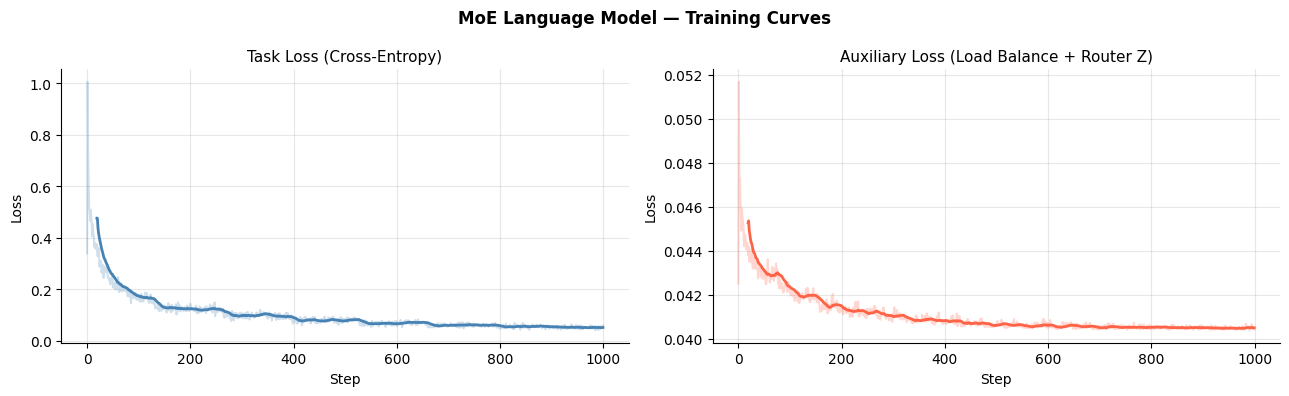

In [154]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

def smooth(vals, w=20):
    return np.convolve(vals, np.ones(w)/w, mode='valid')

task = np.array(history['task'])
aux  = np.array(history['aux'])

ax1.plot(task, alpha=0.25, color='steelblue')
ax1.plot(np.arange(len(smooth(task))) + 19, smooth(task), color='steelblue', lw=2)
ax1.set_title('Task Loss (Cross-Entropy)', fontsize=11)
ax1.set_xlabel('Step'); ax1.set_ylabel('Loss')
ax1.grid(True, alpha=0.3)
ax1.spines[['top','right']].set_visible(False)

ax2.plot(aux, alpha=0.25, color='tomato')
ax2.plot(np.arange(len(smooth(aux))) + 19, smooth(aux), color='tomato', lw=2)
ax2.set_title('Auxiliary Loss (Load Balance + Router Z)', fontsize=11)
ax2.set_xlabel('Step'); ax2.set_ylabel('Loss')
ax2.grid(True, alpha=0.3)
ax2.spines[['top','right']].set_visible(False)

plt.suptitle('MoE Language Model — Training Curves', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('moe_lm_training.png', dpi=150, bbox_inches='tight')
plt.show()

In [139]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
#  👇  CHANGE THIS TO ANY TEXT YOU WANT
INPUT_TEXT = 'to be or not to be'
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

model.eval()

with torch.no_grad():
    ids = tokenizer.encode(INPUT_TEXT).unsqueeze(0).to(device)  # [1, S]
    logits, _, _, all_info = model(ids)

# ── Next-token prediction ─────────────────────────────────────────────
# logits[:, -1, :] = logits at the LAST position = prediction for what comes next
last_logits  = logits[0, -1, :]                       # [vocab_size]
probs        = F.softmax(last_logits, dim=-1)          # [vocab_size]
top5_probs, top5_ids = torch.topk(probs, 5)            # top-5 predictions

print(f'Input text   : {repr(INPUT_TEXT)}')
print(f'Token ids    : {tokenizer.encode(INPUT_TEXT).tolist()}')
print()
print('Top-5 next token predictions:')
print(f'  {"Token":<10} {"Prob"}')
print('  ' + '-'*22)
for prob, tid in zip(top5_probs.tolist(), top5_ids.tolist()):
    token_str = repr(tokenizer.decode([tid]))
    bar = '█' * int(prob * 40)
    print(f'  {token_str:<12} {prob:.3f}  {bar}')

Input text   : 'to be or not to be'
Token ids    : [1462, 307, 393, 407, 284, 307]

Top-5 next token predictions:
  Token      Prob
  ----------------------
  ' the'       0.291  ███████████
  ' a'         0.078  ███
  ' one'       0.043  █
  ' an'        0.042  █
  ' brought'   0.033  █


## Expert Activation Heatmap per Token

For each token in your input and each layer, we show:
- which experts were selected (✓)
- the gate weight given to each expert (colour intensity)

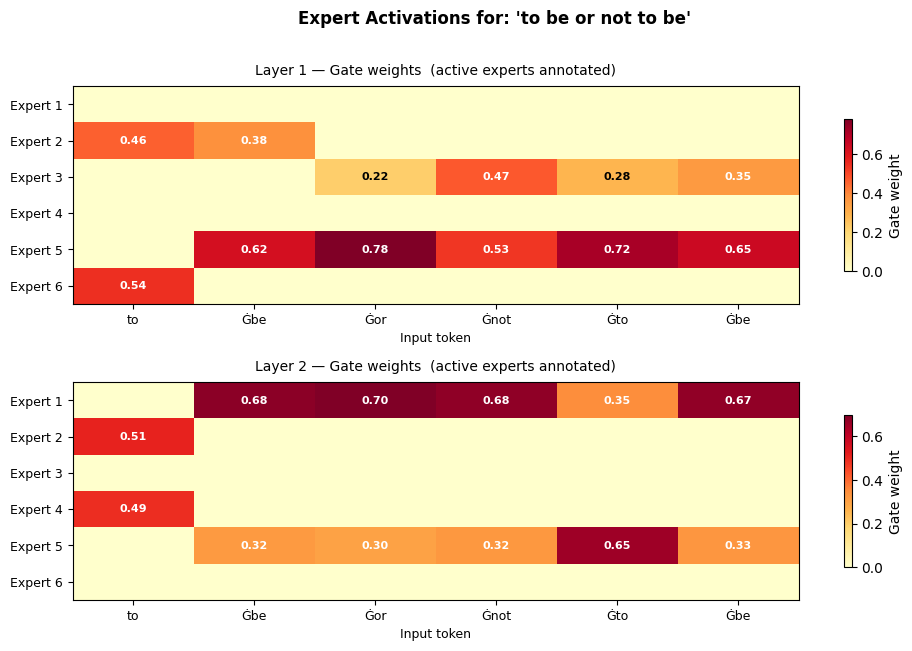

In [155]:
tokens = tokenizer.tokenizer.convert_ids_to_tokens(tokenizer.encode(INPUT_TEXT).tolist())
S      = len(tokens)

fig, axes = plt.subplots(
    N_LAYERS, 1,
    figsize=(max(10, S * 0.55 + 2), N_LAYERS * 3.2),
    squeeze=False
)

for layer_idx, (ax, info) in enumerate(zip(axes[:, 0], all_info)):
    # gate_weights: [1, S, N_EXPERTS] → squeeze to [S, N_EXPERTS]
    gate_w = info['weights'][0].cpu().numpy()   # [S, N]
    topk   = info['topk_idx'][0].cpu().numpy()  # [S, K]

    im = ax.imshow(
        gate_w.T,               # shape [N_experts, S] for (y=expert, x=token)
        aspect='auto',
        cmap='YlOrRd',
        vmin=0.0,
        vmax=gate_w.max() + 1e-6,
        interpolation='nearest'
    )

    # Annotate active experts with their gate weight
    for t in range(S):
        for k_slot in range(TOP_K):
            e = topk[t, k_slot]
            w = gate_w[t, e]
            ax.text(
                t, e, f'{w:.2f}',
                ha='center', va='center',
                fontsize=8, fontweight='bold',
                color='white' if w > 0.3 else 'black'
            )

    ax.set_xticks(range(S))
    ax.set_xticklabels(tokens, fontsize=9)
    ax.set_yticks(range(N_EXPERTS))
    ax.set_yticklabels([f'Expert {i+1}' for i in range(N_EXPERTS)], fontsize=9)
    ax.set_title(f'Layer {layer_idx + 1} — Gate weights  (active experts annotated)',
                 fontsize=10, pad=8)
    ax.set_xlabel('Input token', fontsize=9)
    plt.colorbar(im, ax=ax, shrink=0.7, label='Gate weight')

plt.suptitle(
    f'Expert Activations for: {repr(INPUT_TEXT)}',
    fontsize=12, fontweight='bold', y=1.01
)
plt.tight_layout()
plt.savefig('moe_expert_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

In [156]:
print(f'Input: {repr(INPUT_TEXT)}\n')
print(f'{"Pos":<4} {"Token":<8} ', end='')
for layer_idx in range(N_LAYERS):
    print(f'  Layer {layer_idx+1} experts', end='')
print()
print('-' * (12 + N_LAYERS * 22))

for t, char in enumerate(tokens):
    print(f'{t:<4} {repr(char):<8} ', end='')
    for layer_idx, info in enumerate(all_info):
        topk = info['topk_idx'][0, t].cpu().tolist()     # K expert indices
        wts  = info['weights'][0, t].cpu()               # N weights
        parts = [f'E{e+1}({wts[e]:.2f})' for e in topk]
        print(f"  {', '.join(parts):<20}", end='')
    print()

Input: 'to be or not to be'

Pos  Token      Layer 1 experts  Layer 2 experts
--------------------------------------------------------
0    'to'       E6(0.54), E2(0.46)    E2(0.51), E4(0.49)  
1    'Ġbe'      E5(0.62), E2(0.38)    E1(0.68), E5(0.32)  
2    'Ġor'      E5(0.78), E3(0.22)    E1(0.70), E5(0.30)  
3    'Ġnot'     E5(0.53), E3(0.47)    E1(0.68), E5(0.32)  
4    'Ġto'      E5(0.72), E3(0.28)    E5(0.65), E1(0.35)  
5    'Ġbe'      E5(0.65), E3(0.35)    E1(0.67), E5(0.33)  


In [157]:
def generate(model, tokenizer, prompt: str, max_new_tokens: int = 40, temperature: float = 1.0):
    """
    Autoregressively generate text from a prompt.

    temperature : float
        1.0  = sample from the model's distribution as-is
        <1.0 = sharper / more confident (lower temperature = more repetitive)
        >1.0 = flatter / more random
    """
    model.eval()
    ids = tokenizer.encode(prompt).unsqueeze(0).to(device)   # [1, S]
    generated = tokenizer.decode(ids[0])

    with torch.no_grad():
        for _ in range(max_new_tokens):
            # Crop to max_seq if needed.
            ids_crop = ids[:, -MAX_SEQ:]

            logits, _, _, _ = model(ids_crop)           # [1, S, V]
            next_logits = logits[0, -1, :]              # [V] - last position

            # Apply temperature.
            next_logits = next_logits / temperature
            probs = F.softmax(next_logits, dim=-1)

            # Sample from the distribution.
            next_id = torch.multinomial(probs, num_samples=1)   # [1]
            ids = torch.cat([ids, next_id.unsqueeze(0)], dim=1)
            generated += tokenizer.decode([next_id.item()])

    return generated


# Try different prompts and temperatures
for prompt, temp in [
    ('to be or not',  1.0),
    ('the quality of', 0.8),
    ('all the world', 1.2),
]:
    out = generate(model, tokenizer, prompt, max_new_tokens=40, temperature=temp)
    print(f'[temp={temp}] {repr(out)}')
    print()

[temp=1.0] 'to be or not keeping the know. Brazau��s conduct was ��despicable�� and his beliefs ��repugnant,�� the maximum sentence of six months for a summary conviction on'

[temp=0.8] 'the quality of the White House.\n\nWith the lesson of Michigan in mind, her campaign moved to retool her stance on trade by strengthening her opposition to the Trans-Pacific Partnership and emphasizing support for manufacturing in'

[temp=1.2] 'all the world tour, it ended perfectly. If there is another years from now, though, I can��t wait to be there too.\nShops like the Wrenchmonkees and Unique. But'

